# **Importing Libraries**

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset

import warnings
warnings.filterwarnings('ignore')

d:\Projects\sentiment-analysis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# **Loading the data from HF**

In [4]:
emotion_data = load_dataset('dair-ai/emotion')
emotion_data

Generating test split: 100%|██████████| 2000/2000 [00:00<00:00, 107824.11 examples/s]


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [5]:
train_text = emotion_data['train']['text']
train_label = emotion_data['train']['label']

test_text = emotion_data['test']['text']
test_label = emotion_data['test']['label']

In [6]:
label_names = emotion_data['train'].features['label'].names
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [7]:
train_df = pd.DataFrame(
    {
        'text': train_text,
        'label': [label_names[i] for i in train_label]
     }
)

In [8]:
train_df.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [9]:
test_df = pd.DataFrame(
    {
        'text': test_text,
        'label': [label_names[i] for i in test_label]
    }
)

test_df.head()

,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


In [10]:
train_df.isnull().sum()

text     0
label    0
dtype: int64

In [11]:
test_df.isnull().sum()

text     0
label    0
dtype: int64

# **Exploratory Data Analysis**

In [12]:
train_df['label'].value_counts()

label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

<Axes: xlabel='label', ylabel='count'>

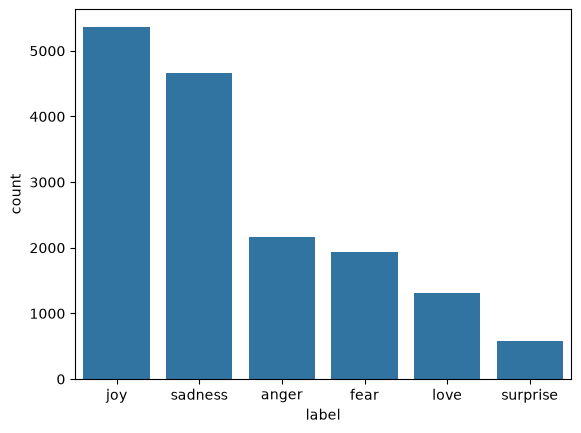

In [13]:
sns.countplot(x = 'label', data = train_df, order = train_df['label'].value_counts().index)

The data is imbalanced with more "joy" labels

# **Data Preprocessing**

In [14]:
train_df.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [15]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

# tokenizing the text
tokenizer = Tokenizer(num_words = max_words, oov_token = '')

tokenizer.fit_on_texts(train_df['text'])

In [16]:
# words to numbers (unique -> higher number)
train_seq = tokenizer.texts_to_sequences(train_df['text'])
test_seq = tokenizer.texts_to_sequences(test_df['text'])


In [17]:
# to have same input size at all times we use padded seq i.e, we add 0s at the end to cover the input size

padded_train_seq = pad_sequences(train_seq, maxlen= 50, padding = 'post', truncating = 'post')
padded_test_seq = pad_sequences(test_seq, maxlen= 50, padding = 'post', truncating = 'post')

In [18]:
train_labels = np.array(train_label)
test_labels = np.array(test_label)

In [19]:
num_classes = len(np.unique(train_labels))
num_classes

6

In [20]:
print(f"Vocal size : {len(tokenizer.word_index)}")
print(f"Max Sentence length: {padded_train_seq.shape[1]}")

Vocal size : 15213
Max Sentence length: 50


In [22]:
from sklearn.utils import class_weight

# weight = total_samples / (num_classes * samples_in_that_class)

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(train_labels),
    y = train_labels
)

class_weights

array([0.57151022, 0.49732687, 2.04498978, 1.23513973, 1.37669936,
       4.66200466])

In [23]:
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights = True
)

# **Training Models**

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, Bidirectional, GRU


Simple RNN

In [26]:
rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128, input_length = 50),
    SimpleRNN(units = 128, return_sequences = True),
    Dropout(0.5),
    SimpleRNN(units = 64),
    Dropout(0.5),
    Dense(units = num_classes, activation = 'softmax')
])

rnn_model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'] )

rnn_model.fit(
    padded_train_seq,
    train_labels,
    epochs = 20,
    batch_size = 32,
    validation_data = (padded_test_seq, test_labels),
    callbacks = [early_stopping],
    class_weight = class_weight_dict
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 45ms/step - accuracy: 0.1561 - loss: 1.8895 - val_accuracy: 0.1010 - val_loss: 1.8328
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.1632 - loss: 1.7975 - val_accuracy: 0.1535 - val_loss: 1.7902
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.1719 - loss: 1.7775 - val_accuracy: 0.1050 - val_loss: 1.8041
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.1647 - loss: 1.7553 - val_accuracy: 0.1020 - val_loss: 1.8343
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 53ms/step - accuracy: 0.1624 - loss: 1.7397 - val_accuracy: 0.1025 - val_loss: 1.8767


In [27]:
rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_seq, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1535 - loss: 1.7902
RNN Loss: 1.7902238368988037
RNN Accuracy: 0.1535000056028366


LSTM

In [28]:
lstm_model = Sequential([
    Embedding( input_dim = 10000, output_dim = 128, input_length = 50),
    LSTM(units = 128, return_sequences = True),
    Dropout(0.5),
    LSTM(units = 64),
    Dropout(0.5),
    Dense(units = num_classes, activation = 'softmax')
])

lstm_model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'] )
lstm_model.fit(
    padded_train_seq,
    train_labels,
    epochs = 20,
    batch_size = 32,
    validation_data = (padded_test_seq, test_labels),
    callbacks = [early_stopping],
    class_weight = class_weight_dict
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_seq, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 47s 77ms/step - accuracy: 0.1487 - loss: 1.7956 - val_accuracy: 0.0335 - val_loss: 1.8012
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 71ms/step - accuracy: 0.1558 - loss: 1.7934 - val_accuracy: 0.0790 - val_loss: 1.7924
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.1562 - loss: 1.7879 - val_accuracy: 0.0580 - val_loss: 1.7999
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.2101 - loss: 1.6903 - val_accuracy: 0.1860 - val_loss: 1.7180
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.3193 - loss: 1.3780 - val_accuracy: 0.2665 - val_loss: 1.3865
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.4736 - loss: 1.0190 - val_accuracy: 0.3950 - val_loss: 1.1518
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.7256 - loss: 0.7162 - val_accuracy: 0.8290 - val_loss: 0.6394
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.8789 - loss: 0.4556 - 

GRU

In [29]:
gru_model = Sequential([
    Embedding( input_dim = 10000, output_dim = 128, input_length = 50),
    GRU(units = 128, return_sequences = True),
    Dropout(0.5),
    GRU(units = 64),
    Dropout(0.5),
    Dense(units = num_classes, activation = 'softmax')
])

gru_model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'] )
gru_model.fit(
    padded_train_seq,
    train_labels,
    epochs = 20,
    batch_size = 32,
    validation_data = (padded_test_seq, test_labels),
    callbacks = [early_stopping],
    class_weight = class_weight_dict
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_seq, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 32s 57ms/step - accuracy: 0.1486 - loss: 1.7960 - val_accuracy: 0.2915 - val_loss: 1.7651
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.1626 - loss: 1.7955 - val_accuracy: 0.3460 - val_loss: 1.7781
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.1601 - loss: 1.7938 - val_accuracy: 0.0825 - val_loss: 1.7847
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.1393 - loss: 1.7924 - val_accuracy: 0.3445 - val_loss: 1.7840
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2915 - loss: 1.7651
GRU Loss: 1.7650620937347412
GRU Accuracy: 0.2915000021457672


In [30]:
result_df = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'Loss': [rnn_loss, lstm_loss, gru_loss],
    'Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
}).sort_values(by='Accuracy', ascending = False)

result_df

,Model,Loss,Accuracy
1,LSTM,0.371599,0.8965
2,GRU,1.765062,0.2915
0,RNN,1.790224,0.1535


Bidirectional GRU

In [31]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding( input_dim = 10000, output_dim = 128, input_length = 50),
    Bidirectional(GRU(units = 128, return_sequences = True) ),
    Dropout(0.5),
    Bidirectional(GRU(units = 64)),
    Dropout(0.5),
    Dense(units = num_classes, activation = 'softmax')
])

In [32]:
BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [33]:
BiGRU.fit(
    padded_train_seq,
    train_labels,
    epochs = 20,
    batch_size = 32,
    validation_data = (padded_test_seq, test_labels),
    callbacks = [early_stopping],
    class_weight = class_weight_dict
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 75ms/step - accuracy: 0.5327 - loss: 1.1601 - val_accuracy: 0.8800 - val_loss: 0.3996
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 73ms/step - accuracy: 0.9091 - loss: 0.2774 - val_accuracy: 0.9145 - val_loss: 0.2412
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 73ms/step - accuracy: 0.9366 - loss: 0.1765 - val_accuracy: 0.9240 - val_loss: 0.1999
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 74ms/step - accuracy: 0.9540 - loss: 0.1257 - val_accuracy: 0.9200 - val_loss: 0.2679
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 76ms/step - accuracy: 0.9643 - loss: 0.0916 - val_accuracy: 0.9120 - val_loss: 0.3124
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 74ms/step - accuracy: 0.9704 - loss: 0.0828 - val_accuracy: 0.9120 - val_loss: 0.2702


In [34]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_seq, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9240 - loss: 0.1999
BiGRU Loss: 0.19988927245140076
BiGRU Accuracy: 0.9240000247955322


# **Evaluation**

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step


<Axes: >

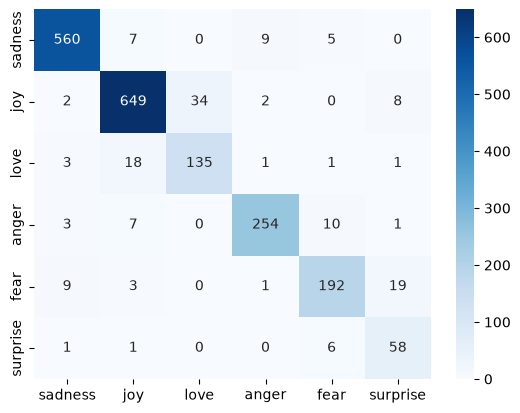

In [35]:
from sklearn.metrics import confusion_matrix

BiGRU_preds = np.argmax(BiGRU.predict(padded_test_seq),axis=1)

sns.heatmap(confusion_matrix(test_labels, BiGRU_preds),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)

# **Final Predictions**

In [36]:
sample_texts = [
    "I cant believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless now",
    "I was so furious that they cancelled the trip at the last moment.",
    "I feel terrified while walking down the dark streets alone at night.",
    "I was shocked and completely suprized by the unexpected gifts!."
]

In [37]:
sample_seq = tokenizer.texts_to_sequences(sample_texts)
sample_padded_seq = pad_sequences(sample_seq, maxlen= 50, padding = 'post', truncating = 'post')

In [38]:
sample_preds = np.argmax(BiGRU.predict(sample_padded_seq),axis=1)

for i in range(len(sample_texts)):
    print(f'Text: {sample_texts[i]}')
    print(f'Predicted Label: {label_names[sample_preds[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Text: I cant believe how happy I am right now, this is amazing!
Predicted Label: joy
Text: I feel so alone and hopeless now
Predicted Label: sadness
Text: I was so furious that they cancelled the trip at the last moment.
Predicted Label: anger
Text: I feel terrified while walking down the dark streets alone at night.
Predicted Label: fear
Text: I was shocked and completely suprized by the unexpected gifts!.
Predicted Label: surprise


# **Save and Export the Model**

In [39]:
import os
import pickle

model_directory = '../artifacts'
os.makedirs(model_directory, exist_ok=True)

In [40]:
# save model

BiGRU.save(os.path.join(model_directory, 'model.keras'))

In [41]:
# Save the tokenizer
tokenizer_path = os.path.join(model_directory, 'tokenizer.pkl')
with open(tokenizer_path, 'wb') as file:
    pickle.dump(tokenizer, file)